PROYECTO SEMILLA


1.Definición del problema

La desnutrición infantil constituye un problema relevante para la salud y el desarrollo durante los primeros años de vida. El periodo de 0 a 36 meses es especialmente importante debido al crecimiento acelerado, la lactancia, la introducción de la alimentación complementaria y la exposición a enfermedades.

Aunque los programas de atención nutricional permiten identificar y atender a los niños que ya presentan riesgo o desnutrición, existe una oportunidad de fortalecer la prevención, identificando dentro de la población actualmente clasificada como sin riesgo aquellos perfiles que presentan características que podrían representar una mayor vulnerabilidad nutricional.

En este contexto, se propone utilizar técnicas de aprendizaje no supervisado para identificar patrones en variables sociodemográficas, alimentarias y de salud, sin asumir previamente cuáles son los grupos existentes

2. Objetivo general

Identificar perfiles de vulnerabilidad nutricional entre niños y niñas de 0 a 36 meses que actualmente no presentan riesgo nutricional, mediante técnicas de aprendizaje no supervisado, considerando factores sociodemográficos, alimentarios y de salud.

Objetivos específicos
**Explorar y caracterizar las variables sociodemográficas, alimentarias y de salud de la población seleccionada.
**Preparar y depurar los datos mediante el tratamiento de valores faltantes y la estandarización de las variables.
**Identificar perfiles de niños mediante el algoritmo K-Means.
**Identificar agrupaciones y observaciones atípicas mediante DBSCAN.
**Interpretar los perfiles encontrados desde una perspectiva de prevención y seguimiento nutricional infantil.

3.  Pregunta de investigación

¿Qué perfiles de vulnerabilidad nutricional pueden identificarse entre los niños de 0 a 36 meses que actualmente no presentan riesgo de desnutrición, considerando factores sociodemográficos, alimentarios y de salud?

4. Justificacion del Dataset

Utilizamos la Encuesta Nacional de Niños, Niñas y Mujeres (ENIM 2015) de México, correspondiente a la implementación mexicana de la Multiple Indicator Cluster Survey (MICS).

La base contiene información relacionada con diferentes dimensiones del bienestar infantil, incluyendo características sociodemográficas, alimentación, lactancia, vacunación, enfermedades recientes y mediciones antropométricas.

La población de interés se delimitó a niños y niñas de 0 a 36 meses, debido a la importancia de esta etapa para el crecimiento, la alimentación complementaria y la prevención de alteraciones nutricionales.

La base original contenía 8.216 registros y 409 variables

5. Obtención y comprensión de los datos
A diferencia de un modelo supervisado, en este proyecto no buscamos predecir una etiqueta conocida. El objetivo es descubrir estructuras y perfiles dentro de una población que actualmente se encuentra clasificada como sin riesgo.
Fuente

ENIM 2015 – MICS México

Población seleccionada

Niños y niñas de 0 a 36 meses.

Base inicial

La base original contiene:

8.216 registros y 409 variables.


In [110]:
#Importar librerias
# Manipulación de datos
import pandas as pd
import numpy as np


# Visualización
import matplotlib.pyplot as plt


In [111]:
#poder leer archivo sav
!pip install pyreadstat

In [112]:
#cargar el archivo
from google.colab import files

uploaded = files.upload()

Saving ch.sav to ch (1).sav


In [113]:
#importar libreria para leer el diccionario de la encuesta
import pyreadstat

df, meta = pyreadstat.read_sav("ch.sav")

In [114]:
#leer en dataset
df.head()

,HH1,HH2,UF1,UF2,UF4,UF6,UF8D,UF8M,UF8Y,UF9,...,mage,melevel,ethnicity,chweight,wscore,windex5,wscoreu,windex5u,wscorer,windex5r
0,1.0,1.0,1.0,1.0,5.0,2.0,30.0,10.0,2015.0,1.0,...,35.0,4.0,2.0,1.531297,1.068160,5.0,0.934095,4.0,NaN,NaN
1,1.0,3.0,1.0,3.0,2.0,1.0,31.0,10.0,2015.0,1.0,...,42.0,4.0,2.0,0.480290,0.695821,4.0,0.432322,3.0,NaN,NaN
2,1.0,5.0,1.0,5.0,3.0,2.0,29.0,10.0,2015.0,1.0,...,24.0,3.0,2.0,0.480290,-0.200284,2.0,-0.775291,1.0,NaN,NaN
3,1.0,5.0,1.0,5.0,4.0,2.0,29.0,10.0,2015.0,1.0,...,24.0,3.0,2.0,0.480290,-0.200284,2.0,-0.775291,1.0,NaN,NaN
4,1.0,5.0,1.0,5.0,5.0,2.0,29.0,10.0,2015.0,1.0,...,24.0,3.0,2.0,0.480290,-0.200284,2.0,-0.775291,1.0,NaN,NaN


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8216 entries, 0 to 8215
Columns: 409 entries, HH1 to windex5r
dtypes: float64(292), object(117)
memory usage: 25.6+ MB


In [116]:
#verificar columnas
df.columns

Index(['HH1', 'HH2', 'UF1', 'UF2', 'UF4', 'UF6', 'UF8D', 'UF8M', 'UF8Y', 'UF9',
       ...
       'mage', 'melevel', 'ethnicity', 'chweight', 'wscore', 'windex5',
       'wscoreu', 'windex5u', 'wscorer', 'windex5r'],
      dtype='object', length=409)

In [117]:
#ver columna oir columna para visualizar la informacion que contiene
meta.column_names_to_labels

{'HH1': 'Número de conglomerado',
 'HH2': 'Número de hogar',
 'UF1': 'Número de conglomerado',
 'UF2': 'Número de hogar',
 'UF4': 'Número de línea del niño',
 'UF6': 'Numero de residente de la madre/cuidadora',
 'UF8D': 'Dia de la entrevista',
 'UF8M': 'Mes de la entrevista',
 'UF8Y': 'Año de la entrevista',
 'UF9': 'Resultado de la entrevisa-cuestionario niño/a',
 'UF10A': 'Código del supervisor',
 'UF12H': 'Inicio de la entrevista-Hora',
 'UF12M': 'Inicio de la entrevista-Minutos',
 'UF13H': 'Final de la entrevista-hora',
 'UF13M': 'Final de la entrevista-Minutos',
 'AG1D': 'Dia de nacimiento del niño',
 'AG1M': 'Mes de nacimiento del niño',
 'AG1Y': 'Año de nacimiento del niño',
 'AG2': 'Edad del niño/a',
 'AG3A': 'Seguro Social (IMSS)',
 'AG3B': 'IMSS-Solidaridad-Oportunidades-Prospera',
 'AG3C': 'ISSSTE o ISSSTE Estatal',
 'AG3D': 'Pemex, Defensa o Marina',
 'AG3E': 'Seguro Popular o Para una nueva generación o Siglo XXI?',
 'AG3F': 'Seguro Privado',
 'AG3X': 'Otro seguro',
 'AG3Z


Se realizo una  una selección de variables relevantes para el proyecto.

Base de trabajo

Actualmente se trabajara con 18 variables:

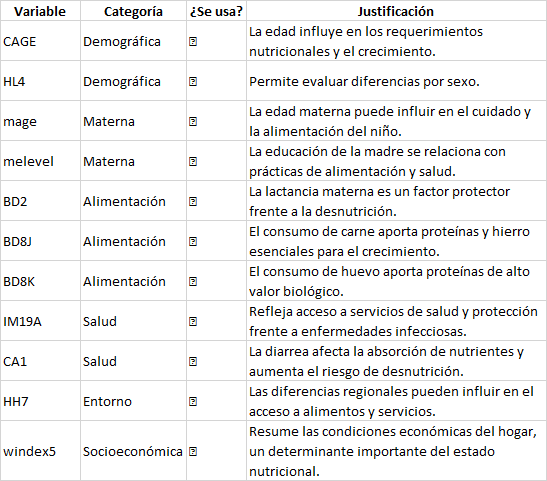

In [118]:
#crear un nuevo dataset con las variables objetivas
variables = [
    "CAGE",
    "HL4",
    "mage",
    "melevel",
    "HH6",
    "HH7",
    "windex5",
    "BD2",
    "BD3",
    "BD8B",
    "BD8J",
    "BD8K",
    "BD11",
    "IM19A",
    "CA1",
    "CA6AA",
    "CA7",
    "WHZ2"
]

In [119]:
#crear copia
df_ml = df[variables].copy()

In [120]:
#crear copia del orginal
df_ml = df[variables].copy()

In [121]:
#renombrar variables
renombrar = {
    "CAGE": "edad_meses",
    "HL4": "sexo",
    "mage": "edad_madre",
    "melevel": "educacion_madre",
    "HH6": "area",
    "HH7": "region",
    "windex5": "quintil_riqueza",
    "BD2": "lactancia_alguna_vez",
    "BD3": "lactancia_actual",
    "BD8B": "alimento_fortificado",
    "BD8J": "consumo_carne",
    "BD8K": "consumo_huevo",
    "BD11": "numero_comidas",
    "IM19A": "vacunacion_semana_nacional",
    "CA1": "diarrea_ultimas_2_semanas",
    "CA6AA": "fiebre_ultimas_2_semanas",
    "CA7": "tos_ultimas_2_semanas",
    "WHZ2": "zscore_peso_talla"
}

In [122]:
#crear una copia del original
df_ml = df[variables].copy()

df_ml.rename(columns=renombrar, inplace=True)

In [123]:
#verificar valores faltantes
df_ml.isnull().sum()

,0
edad_meses,150
sexo,0
edad_madre,0
educacion_madre,0
area,0
region,0
quintil_riqueza,0
lactancia_alguna_vez,3504
lactancia_actual,3836
alimento_fortificado,3504


In [124]:
#resumen de todas las columnas
df_ml.describe(include="all")

,edad_meses,sexo,edad_madre,educacion_madre,area,region,quintil_riqueza,lactancia_alguna_vez,lactancia_actual,alimento_fortificado,consumo_carne,consumo_huevo,numero_comidas,vacunacion_semana_nacional,diarrea_ultimas_2_semanas,fiebre_ultimas_2_semanas,tos_ultimas_2_semanas,zscore_peso_talla
count,8066.000000,8216.000000,8216.000000,8216.000000,8216.000000,8216.000000,8216.000000,4712.000000,4380.000000,4712.000000,4712.000000,4712.000000,4133.000000,4712.000000,8066.000000,8066.000000,8066.000000,8066.000000
mean,30.667369,1.496105,28.422833,3.216650,1.355648,3.001217,2.445229,1.075552,1.572831,1.828311,1.512733,1.665747,3.168885,1.839559,1.940243,1.900694,1.817878,3.193139
std,17.202166,0.500015,7.736713,0.980663,0.478738,1.418339,1.331822,0.324838,0.504324,0.442418,0.574568,0.550284,1.389363,0.769663,0.482964,0.415666,0.503116,16.801019
min,0.000000,1.000000,11.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-4.600000
25%,16.000000,1.000000,23.000000,3.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,-0.370000
50%,31.000000,1.000000,27.000000,3.000000,1.000000,3.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,0.270000
75%,46.000000,2.000000,33.000000,4.000000,2.000000,4.000000,3.000000,1.000000,2.000000,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000,0.970000
max,59.000000,2.000000,86.000000,9.000000,2.000000,5.000000,5.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,9.000000,8.000000,8.000000,8.000000,99.990000


In [125]:
#saber que inidica cada respuesta en el diccionario de la encuesta

meta.variable_value_labels["BD8J"]

{1.0: 'Si', 2.0: 'No', 8.0: 'No sabe', 9.0: 'Missing'}

In [126]:
meta.variable_value_labels["BD8K"]

{1.0: 'Si', 2.0: 'No', 8.0: 'No sabe', 9.0: 'Missing'}

In [127]:
meta.variable_value_labels["BD11"]

{7.0: '7+', 8.0: 'No sabe'}

Se consultó el diccionario de variables del archivo SPSS para identificar el significado de los códigos de respuesta. En las variables dicotómicas, los valores 8 ("No sabe") y 9 ("Missing") fueron recodificados como valores faltantes (NaN), ya que no representan respuestas válidas para el análisis.

In [128]:
#limpiar datos nulos
variables_si_no = [
    "lactancia_alguna_vez",
    "lactancia_actual",
    "alimento_fortificado",
    "consumo_carne",
    "consumo_huevo",
    "vacunacion_semana_nacional",
    "diarrea_ultimas_2_semanas",
    "fiebre_ultimas_2_semanas",
    "tos_ultimas_2_semanas"
]

df_ml[variables_si_no] = df_ml[variables_si_no].replace({8: pd.NA, 9: pd.NA})

In [129]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8216 entries, 0 to 8215
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   edad_meses                  8066 non-null   float64
 1   sexo                        8216 non-null   float64
 2   edad_madre                  8216 non-null   float64
 3   educacion_madre             8216 non-null   float64
 4   area                        8216 non-null   float64
 5   region                      8216 non-null   float64
 6   quintil_riqueza             8216 non-null   float64
 7   lactancia_alguna_vez        4708 non-null   object 
 8   lactancia_actual            4379 non-null   object 
 9   alimento_fortificado        4706 non-null   object 
 10  consumo_carne               4703 non-null   object 
 11  consumo_huevo               4703 non-null   object 
 12  numero_comidas              4133 non-null   float64
 13  vacunacion_semana_nacional  4661 

como existen columnas que contienen valores de texto es necesario convertilos a numero

In [130]:
#convertir a numero
variables_si_no = [
    "lactancia_alguna_vez",
    "lactancia_actual",
    "alimento_fortificado",
    "consumo_carne",
    "consumo_huevo",
    "vacunacion_semana_nacional",
    "diarrea_ultimas_2_semanas",
    "fiebre_ultimas_2_semanas",
    "tos_ultimas_2_semanas"
]

df_ml[variables_si_no] = df_ml[variables_si_no].apply(pd.to_numeric)

In [131]:
#filtrar edad
df_ml = df_ml[df_ml["edad_meses"] <= 36]


In [132]:
#verificar cuantos datos se perdieron al hacer la limpieza
(df_ml.isnull().sum() / len(df_ml) * 100).round(2)

,0
edad_meses,0.00
sexo,0.00
edad_madre,0.00
educacion_madre,0.00
area,0.00
region,0.00
quintil_riqueza,0.00
lactancia_alguna_vez,1.88
lactancia_actual,8.73
alimento_fortificado,1.92


el riesgo nutricional se evalua internacionalmente segun la siguiente escala
z core  -1 y 0 = bajo peso
zcore -2 y -1= riesgo de desnutricion
z core -2 y -3= desnutricion
A partir de la clasificación nutricional basada en el Z-score peso/talla, se seleccionaron los niños clasificados como sin riesgo nutricional para constituir la población de análisis del Proyecto Semilla.

In [133]:

#verificar categorias de la variable z core
df_ml["zscore_peso_talla"].value_counts(bins=[-np.inf, -2, -1, np.inf])

,count
"(-1.0, inf]",4342
"(-2.0, -1.0]",396
"(-inf, -2.0]",60


In [134]:
df_ml["zscore_peso_talla"].describe()

,zscore_peso_talla
count,4798.000000
mean,3.237691
std,16.929259
min,-3.720000
25%,-0.390000
50%,0.290000
75%,1.010000
max,99.990000


In [135]:

 #verificar el numero de niños con valor 99.99
(df_ml["zscore_peso_talla"] == 99.99).sum()

np.int64(125)

In [136]:
#convertir 99.99 a Nan
df_ml["zscore_peso_talla"] = df_ml["zscore_peso_talla"].replace(99.99, np.nan)

In [137]:
df_ml["zscore_peso_talla"].describe()

,zscore_peso_talla
count,4673.000000
mean,0.649623
std,6.092062
min,-3.720000
25%,-0.400000
50%,0.270000
75%,0.940000
max,99.980000


In [138]:
(df_ml["zscore_peso_talla"] == 99.98).sum()

np.int64(14)

In [139]:
df_ml["zscore_peso_talla"] = df_ml["zscore_peso_talla"].replace(99.98, np.nan)

In [140]:
(df_ml["zscore_peso_talla"] == 99.97).sum()

np.int64(3)

In [141]:
df_ml["zscore_peso_talla"] = df_ml["zscore_peso_talla"].replace(99.98, np.nan)

In [142]:
df_ml.describe()

,edad_meses,sexo,edad_madre,educacion_madre,area,region,quintil_riqueza,lactancia_alguna_vez,lactancia_actual,alimento_fortificado,consumo_carne,consumo_huevo,numero_comidas,vacunacion_semana_nacional,diarrea_ultimas_2_semanas,fiebre_ultimas_2_semanas,tos_ultimas_2_semanas,zscore_peso_talla
count,4798.000000,4798.000000,4798.000000,4798.000000,4798.000000,4798.000000,4798.000000,4708.000000,4379.000000,4706.000000,4703.000000,4703.000000,4133.000000,4661.000000,4773.000000,4788.000000,4788.000000,4659.000000
mean,18.639225,1.497916,27.323051,3.260525,1.360358,3.016465,2.480200,1.069669,1.571363,1.820442,1.500319,1.653625,3.168885,1.771937,1.893149,1.889515,1.816207,0.351142
std,10.414152,0.500048,7.293017,0.977583,0.480154,1.420956,1.301017,0.254615,0.494938,0.383860,0.500053,0.475865,1.389363,0.419628,0.308956,0.313526,0.387356,2.735144
min,0.000000,1.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-3.720000
25%,10.000000,1.000000,22.000000,3.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,-0.410000
50%,19.000000,1.000000,26.000000,3.000000,1.000000,3.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,0.260000
75%,27.000000,2.000000,32.000000,4.000000,2.000000,4.000000,3.000000,1.000000,2.000000,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000,0.930000
max,36.000000,2.000000,73.000000,9.000000,2.000000,5.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,8.000000,2.000000,2.000000,2.000000,2.000000,99.970000


In [143]:
df_ml["zscore_peso_talla"].isnull().sum()

np.int64(139)

In [144]:
#crear copia de la base
df_modelo = df_ml.dropna(subset=["zscore_peso_talla"]).copy()

In [145]:
df_modelo.shape

(4659, 18)

In [146]:
#crear categorias
def clasificar_nutricion(z):
    if z >= -1:
        return "sin_riesgo"
    elif z >= -2:
        return "riesgo_desnutricion"
    else:
        return "desnutricion"

df_modelo["target"] = df_modelo["zscore_peso_talla"].apply(clasificar_nutricion)

In [147]:
df_modelo["target"].value_counts()

,count
target,
sin_riesgo,4206
riesgo_desnutricion,393
desnutricion,60


In [148]:
df_modelo.columns

Index(['edad_meses', 'sexo', 'edad_madre', 'educacion_madre', 'area', 'region',
       'quintil_riqueza', 'lactancia_alguna_vez', 'lactancia_actual',
       'alimento_fortificado', 'consumo_carne', 'consumo_huevo',
       'numero_comidas', 'vacunacion_semana_nacional',
       'diarrea_ultimas_2_semanas', 'fiebre_ultimas_2_semanas',
       'tos_ultimas_2_semanas', 'zscore_peso_talla', 'target'],
      dtype='object')

In [149]:
X = df_modelo.drop(columns=["zscore_peso_talla", "target"])
y = df_modelo["target"]

In [150]:
X.shape, y.shape

((4659, 17), (4659,))

In [151]:

#faltantes
X.isnull().sum()

,0
edad_meses,0
sexo,0
edad_madre,0
educacion_madre,0
area,0
region,0
quintil_riqueza,0
lactancia_alguna_vez,86
lactancia_actual,401
alimento_fortificado,88


In [152]:
X.isnull().mean().mul(100).round(2)

,0
edad_meses,0.00
sexo,0.00
edad_madre,0.00
educacion_madre,0.00
area,0.00
region,0.00
quintil_riqueza,0.00
lactancia_alguna_vez,1.85
lactancia_actual,8.61
alimento_fortificado,1.89


In [153]:
X.dtypes

,0
edad_meses,float64
sexo,float64
edad_madre,float64
educacion_madre,float64
area,float64
region,float64
quintil_riqueza,float64
lactancia_alguna_vez,float64
lactancia_actual,float64
alimento_fortificado,float64


In [154]:
X["sexo"].value_counts(dropna=False)

,count
sexo,
1.0,2332
2.0,2327


In [155]:
X["educacion_madre"].value_counts(dropna=False).sort_index()

,count
educacion_madre,
1.0,110
2.0,897
3.0,1893
4.0,1251
5.0,505
9.0,3


In [156]:
#convertir los valores 9 en Nan ya que no son representativos
X["educacion_madre"] = X["educacion_madre"].replace(9, np.nan)

In [157]:
X["educacion_madre"].isnull().sum()

np.int64(3)

In [158]:
X["area"].value_counts(dropna=False).sort_index()

,count
area,
1.0,2956
2.0,1703


In [159]:
X["region"].value_counts(dropna=False).sort_index()

,count
region,
1.0,857
2.0,1090
3.0,881
4.0,796
5.0,1035


In [160]:
X["quintil_riqueza"].value_counts(dropna=False).sort_index()

,count
quintil_riqueza,
1.0,1397
2.0,1221
3.0,934
4.0,700
5.0,407


In [161]:
X["lactancia_alguna_vez"].value_counts(dropna=False).sort_index()

,count
lactancia_alguna_vez,
1.0,4259
2.0,314
NaN,86


In [162]:
X["lactancia_actual"].value_counts(dropna=False).sort_index()

,count
lactancia_actual,
1.0,1845
2.0,2413
NaN,401


In [163]:
X["alimento_fortificado"].value_counts(dropna=False).sort_index()

,count
alimento_fortificado,
1.0,820
2.0,3751
NaN,88


In [164]:
X["consumo_carne"].value_counts(dropna=False).sort_index()

,count
consumo_carne,
1.0,2282
2.0,2287
NaN,90


In [165]:
X["consumo_huevo"].value_counts(dropna=False).sort_index()

,count
consumo_huevo,
1.0,1583
2.0,2985
NaN,91


In [166]:
X["numero_comidas"].value_counts(dropna=False).sort_index()

,count
numero_comidas,
1.0,339
2.0,972
3.0,1427
4.0,618
5.0,419
6.0,126
7.0,84
8.0,31
NaN,643


In [167]:
X["vacunacion_semana_nacional"].value_counts(dropna=False).sort_index()

,count
vacunacion_semana_nacional,
1.0,1035
2.0,3492
NaN,132


In [168]:
X["diarrea_ultimas_2_semanas"].value_counts(dropna=False).sort_index()

,count
diarrea_ultimas_2_semanas,
1.0,496
2.0,4138
NaN,25


In [169]:
X["fiebre_ultimas_2_semanas"].value_counts(dropna=False).sort_index()

,count
fiebre_ultimas_2_semanas,
1.0,516
2.0,4133
NaN,10


In [170]:
X["tos_ultimas_2_semanas"].value_counts(dropna=False).sort_index()

,count
tos_ultimas_2_semanas,
1.0,858
2.0,3792
NaN,9


In [171]:
X.isnull().sum()

,0
edad_meses,0
sexo,0
edad_madre,0
educacion_madre,3
area,0
region,0
quintil_riqueza,0
lactancia_alguna_vez,86
lactancia_actual,401
alimento_fortificado,88


In [172]:

 #buscar donde esta target
[k for k, v in globals().items() if hasattr(v, "columns") and "target" in v.columns]

['df_modelo']

In [173]:
#nombrar el dataframe
semilla = df_modelo[df_modelo["target"] == "sin_riesgo"].copy()
semilla.shape

(4206, 19)

In [174]:
#verificar columnas
semilla.columns

Index(['edad_meses', 'sexo', 'edad_madre', 'educacion_madre', 'area', 'region',
       'quintil_riqueza', 'lactancia_alguna_vez', 'lactancia_actual',
       'alimento_fortificado', 'consumo_carne', 'consumo_huevo',
       'numero_comidas', 'vacunacion_semana_nacional',
       'diarrea_ultimas_2_semanas', 'fiebre_ultimas_2_semanas',
       'tos_ultimas_2_semanas', 'zscore_peso_talla', 'target'],
      dtype='object')

In [175]:
y.value_counts()

,count
target,
sin_riesgo,4206
riesgo_desnutricion,393
desnutricion,60


In [176]:
semilla = X[y == "sin_riesgo"].copy()

In [177]:
semilla.shape

(4206, 17)

In [178]:
#verificar variables
semilla.isnull().sum()

,0
edad_meses,0
sexo,0
edad_madre,0
educacion_madre,3
area,0
region,0
quintil_riqueza,0
lactancia_alguna_vez,76
lactancia_actual,364
alimento_fortificado,78


In [179]:
#sacarmediana de numero de comidas
semilla["numero_comidas"].median()

3.0

In [180]:
semilla["numero_comidas"] = semilla["numero_comidas"].fillna(3)

Los valores faltantes de numero_comidas fueron reemplazados por la mediana de la variable, cuyo valor fue de 3 comidas. Se eligió la mediana para representar el comportamiento central de los datos sin eliminar registros de la población de estudio.

In [181]:
semilla["lactancia_actual"].value_counts(dropna=False)

,count
lactancia_actual,
2.0,2188
1.0,1654
NaN,364


In [182]:
semilla.groupby("lactancia_actual", dropna=False)["edad_meses"].agg(["count", "min", "max", "mean"])


,count,min,max,mean
lactancia_actual,,,,
1.0,1654,0.0,36.0,11.882709
2.0,2188,1.0,36.0,22.806216
NaN,364,0.0,36.0,24.082418


In [183]:
#aplicar moda
semilla["lactancia_actual"] = semilla["lactancia_actual"].fillna(2)

In [184]:
semilla["lactancia_actual"].isnull().sum()

np.int64(0)

"Los valores faltantes de las variables categóricas fueron imputados utilizando la categoría más frecuente (moda), con el propósito de conservar los registros disponibles para el análisis de agrupamiento."

In [185]:
semilla["lactancia_alguna_vez"].value_counts(dropna=False)

,count
lactancia_alguna_vez,
1.0,3843
2.0,287
NaN,76


In [186]:
semilla.groupby("lactancia_alguna_vez", dropna=False)["edad_meses"].agg(["count", "min", "max", "mean"])

,count,min,max,mean
lactancia_alguna_vez,,,,
1.0,3843,0.0,36.0,18.104606
2.0,287,0.0,36.0,21.111498
NaN,76,13.0,36.0,35.328947


In [187]:
#aplicar moda
semilla["lactancia_alguna_vez"] = semilla["lactancia_alguna_vez"].fillna(1)

In [188]:
semilla["lactancia_alguna_vez"].isnull().sum()

np.int64(0)

In [189]:
semilla.groupby("alimento_fortificado", dropna=False)["edad_meses"].agg(["count", "min", "max", "mean"])

,count,min,max,mean
alimento_fortificado,,,,
1.0,725,2.0,36.0,15.626207
2.0,3403,0.0,36.0,18.873935
NaN,78,6.0,36.0,35.423077


In [190]:
semilla["alimento_fortificado"] = semilla["alimento_fortificado"].fillna(2)

In [191]:
semilla["alimento_fortificado"].isnull().sum()

np.int64(0)

Los valores faltantes de las variables categóricas fueron imputados mediante la categoría más frecuente de cada variable, con el fin de conservar los registros para el análisis no supervisado.

In [192]:
semilla.groupby("consumo_carne", dropna=False)["edad_meses"].agg(["count", "min", "max", "mean"])

,count,min,max,mean
consumo_carne,,,,
1.0,2070,1.0,36.0,22.648792
2.0,2056,0.0,36.0,13.945039
NaN,80,1.0,36.0,34.575000


In [193]:
semilla["consumo_carne"] = semilla["consumo_carne"].fillna(1)

In [194]:
semilla["consumo_carne"].isnull().sum()

np.int64(0)

In [195]:
semilla["consumo_huevo"].value_counts(dropna=False)

,count
consumo_huevo,
2.0,2686
1.0,1439
NaN,81


In [196]:
semilla["consumo_huevo"] = semilla["consumo_huevo"].fillna(2)

In [197]:
semilla["consumo_huevo"].isnull().sum()

np.int64(0)

In [198]:
semilla["vacunacion_semana_nacional"].value_counts(dropna=False)

,count
vacunacion_semana_nacional,
2.0,3144
1.0,944
NaN,118


In [199]:
semilla["vacunacion_semana_nacional"] = semilla["vacunacion_semana_nacional"].fillna(2)

In [200]:
semilla["vacunacion_semana_nacional"].isnull().sum()

np.int64(0)

In [201]:
semilla["diarrea_ultimas_2_semanas"].value_counts(dropna=False)

,count
diarrea_ultimas_2_semanas,
2.0,3748
1.0,438
NaN,20


In [202]:
semilla["diarrea_ultimas_2_semanas"] = semilla["diarrea_ultimas_2_semanas"].fillna(2)

In [203]:
semilla["diarrea_ultimas_2_semanas"].isnull().sum()

np.int64(0)

In [204]:
semilla["tos_ultimas_2_semanas"].value_counts(dropna=False)

,count
tos_ultimas_2_semanas,
2.0,3431
1.0,768
NaN,7


In [205]:
semilla["tos_ultimas_2_semanas"] = semilla["tos_ultimas_2_semanas"].fillna(2)

In [206]:
semilla["tos_ultimas_2_semanas"].isnull().sum()

np.int64(0)

In [207]:
semilla["fiebre_ultimas_2_semanas"].value_counts(dropna=False)

,count
fiebre_ultimas_2_semanas,
2.0,3747
1.0,449
NaN,10


In [208]:
semilla["fiebre_ultimas_2_semanas"] = semilla["fiebre_ultimas_2_semanas"].fillna(2)

In [209]:
semilla["fiebre_ultimas_2_semanas"].isnull().sum()

np.int64(0)

In [210]:
semilla.isnull().sum()

,0
edad_meses,0
sexo,0
edad_madre,0
educacion_madre,3
area,0
region,0
quintil_riqueza,0
lactancia_alguna_vez,0
lactancia_actual,0
alimento_fortificado,0


In [211]:
semilla["educacion_madre"] = semilla["educacion_madre"].fillna(3)

In [212]:
semilla.isnull().sum()

,0
edad_meses,0
sexo,0
edad_madre,0
educacion_madre,0
area,0
region,0
quintil_riqueza,0
lactancia_alguna_vez,0
lactancia_actual,0
alimento_fortificado,0


In [213]:
semilla.dtypes

,0
edad_meses,float64
sexo,float64
edad_madre,float64
educacion_madre,float64
area,float64
region,float64
quintil_riqueza,float64
lactancia_alguna_vez,float64
lactancia_actual,float64
alimento_fortificado,float64


In [214]:
#importar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
semilla_scaled = scaler.fit_transform(semilla)

In [215]:
semilla.shape

(4206, 17)

In [216]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []

for k in range(2, 9):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(semilla_scaled)
    inercia.append(modelo.inertia_)

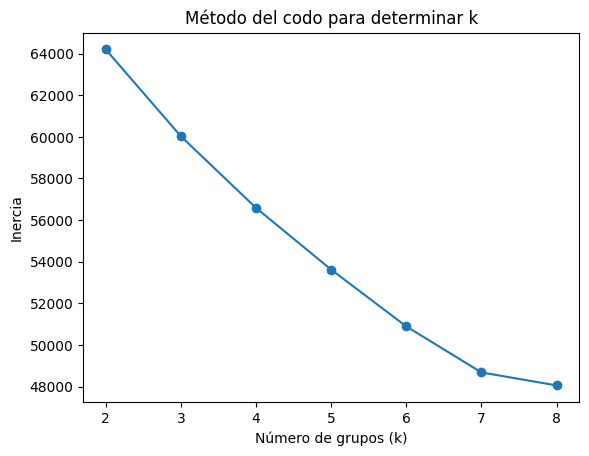

In [217]:
plt.plot(range(2, 9), inercia, marker="o")
plt.xlabel("Número de grupos (k)")
plt.ylabel("Inercia")
plt.title("Método del codo para determinar k")
plt.show()

In [218]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

semilla["cluster_kmeans"] = kmeans.fit_predict(semilla_scaled)

In [219]:
semilla["cluster_kmeans"].value_counts().sort_index()

,count
cluster_kmeans,
0,287
1,1217
2,981
3,1322
4,399


In [220]:
perfil_kmeans = semilla.groupby("cluster_kmeans").mean()

perfil_kmeans

,edad_meses,sexo,edad_madre,educacion_madre,area,region,quintil_riqueza,lactancia_alguna_vez,lactancia_actual,alimento_fortificado,consumo_carne,consumo_huevo,numero_comidas,vacunacion_semana_nacional,diarrea_ultimas_2_semanas,fiebre_ultimas_2_semanas,tos_ultimas_2_semanas
cluster_kmeans,,,,,,,,,,,,,,,,,
0,21.111498,1.463415,28.383275,3.135889,1.289199,2.965157,2.696864,2.0,2.000000,1.836237,1.435540,1.574913,3.236934,1.745645,1.864111,1.867596,1.860627
1,7.458505,1.495481,25.506163,3.195563,1.376335,2.977814,2.289236,1.0,1.156122,1.770748,1.876746,1.919474,2.685292,1.946590,2.000000,1.930156,1.856204
2,24.877676,1.548420,28.457696,2.677880,1.755352,3.439348,1.446483,1.0,1.727829,1.865443,1.402650,1.549439,3.080530,1.726809,2.000000,1.883792,1.816514
3,23.712557,1.503782,27.699697,3.786687,1.069592,2.615734,3.427383,1.0,1.847201,1.838880,1.213313,1.521180,3.614977,1.670197,2.000000,1.907716,1.791982
4,18.624060,1.451128,27.100251,3.135338,1.398496,3.453634,2.220551,1.0,1.604010,1.864662,1.468672,1.639098,3.122807,1.744361,1.000000,1.774436,1.754386


In [221]:
semilla.groupby("cluster_kmeans").mean().round(2).T

cluster_kmeans,0,1,2,3,4
edad_meses,21.11,7.46,24.88,23.71,18.62
sexo,1.46,1.50,1.55,1.50,1.45
edad_madre,28.38,25.51,28.46,27.70,27.10
educacion_madre,3.14,3.20,2.68,3.79,3.14
area,1.29,1.38,1.76,1.07,1.40
region,2.97,2.98,3.44,2.62,3.45
quintil_riqueza,2.70,2.29,1.45,3.43,2.22
lactancia_alguna_vez,2.00,1.00,1.00,1.00,1.00
lactancia_actual,2.00,1.16,1.73,1.85,1.60
alimento_fortificado,1.84,1.77,1.87,1.84,1.86


In [222]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    semilla_scaled,
    semilla["cluster_kmeans"]
)

silhouette

np.float64(0.10710897797031593)

Se aplicó K-Means para identificar perfiles dentro de los 4.206 niños.

El análisis del número de clusters llevó a seleccionar k = 5.

Los cinco grupos quedaron distribuidos así:

Cluster	Niños
0	287
1	1.217
2	981
3	1.322
4	399
Total	4.206

El resultado permitió observar que los niños sin riesgo no constituyen necesariamente una población homogénea, sino que pueden organizarse en diferentes perfiles según sus características.

El coeficiente Silhouette obtenido fue aproximadamente 0,107, lo que indica una separación limitada entre los grupos. Esto debe interpretarse como una característica del conjunto de datos y no como un fracaso del análisis.

In [223]:
from sklearn.cluster import DBSCAN

In [224]:
for eps in [0.8, 1.0, 1.2, 1.5, 2.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    etiquetas = dbscan.fit_predict(semilla_scaled)

    n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    n_ruido = list(etiquetas).count(-1)

    print(
        "eps:", eps,
        "| grupos:", n_clusters,
        "| ruido:", n_ruido
    )

eps: 0.8 | grupos: 0 | ruido: 4206
eps: 1.0 | grupos: 4 | ruido: 4133
eps: 1.2 | grupos: 7 | ruido: 3902
eps: 1.5 | grupos: 14 | ruido: 3558
eps: 2.0 | grupos: 38 | ruido: 2634


In [225]:
for eps in [1.2, 1.5, 1.8, 2.0, 2.2, 2.5]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    etiquetas = dbscan.fit_predict(semilla_scaled)

    n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    n_ruido = list(etiquetas).count(-1)

    print(
        "eps:", eps,
        "| grupos:", n_clusters,
        "| ruido:", n_ruido,
        "| porcentaje ruido:", round(n_ruido / len(semilla) * 100, 2), "%"
    )

eps: 1.2 | grupos: 37 | ruido: 3568 | porcentaje ruido: 84.83 %
eps: 1.5 | grupos: 52 | ruido: 2995 | porcentaje ruido: 71.21 %
eps: 1.8 | grupos: 76 | ruido: 2280 | porcentaje ruido: 54.21 %
eps: 2.0 | grupos: 88 | ruido: 1967 | porcentaje ruido: 46.77 %
eps: 2.2 | grupos: 38 | ruido: 1581 | porcentaje ruido: 37.59 %
eps: 2.5 | grupos: 19 | ruido: 1027 | porcentaje ruido: 24.42 %


In [226]:
for eps in [2.6, 2.8, 3.0, 3.2, 3.5]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    etiquetas = dbscan.fit_predict(semilla_scaled)

    n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    n_ruido = list(etiquetas).count(-1)

    print(
        "eps:", eps,
        "| grupos:", n_clusters,
        "| ruido:", n_ruido,
        "| porcentaje ruido:", round(n_ruido / len(semilla) * 100, 2), "%"
    )

eps: 2.6 | grupos: 14 | ruido: 872 | porcentaje ruido: 20.73 %
eps: 2.8 | grupos: 13 | ruido: 609 | porcentaje ruido: 14.48 %
eps: 3.0 | grupos: 10 | ruido: 402 | porcentaje ruido: 9.56 %
eps: 3.2 | grupos: 9 | ruido: 257 | porcentaje ruido: 6.11 %
eps: 3.5 | grupos: 4 | ruido: 125 | porcentaje ruido: 2.97 %


In [227]:
dbscan = DBSCAN(eps=3.5, min_samples=5)
etiquetas = dbscan.fit_predict(semilla_scaled)

semilla["cluster"] = etiquetas

print(semilla["cluster"].value_counts().sort_index())

cluster
-1     125
 0    3838
 1     231
 2       7
 3       5
Name: count, dtype: int64


Posteriormente se utilizó DBSCAN como segunda técnica de aprendizaje no supervisado.

El modelo permitió identificar grupos según la densidad de las observaciones y, a diferencia de K-Means, también permitió identificar observaciones que no encajaban claramente en los grupos predominantes.

El resultado fue:

Cluster	Niños
-1 — ruido	125
0	3.838
1	231
2	7
3	5
Total	4.206

El grupo -1 corresponde a observaciones que DBSCAN considera ruido o atípicas respecto a la estructura de densidad encontrada
Estos niños presentan combinaciones de características que no se ajustan claramente al patrón predominante de la población y, por ello, podrían constituir un grupo de interés para análisis y seguimiento preventivo

In [228]:
semilla.groupby("cluster").mean(numeric_only=True)

,edad_meses,sexo,edad_madre,educacion_madre,area,region,quintil_riqueza,lactancia_alguna_vez,lactancia_actual,alimento_fortificado,consumo_carne,consumo_huevo,numero_comidas,vacunacion_semana_nacional,diarrea_ultimas_2_semanas,fiebre_ultimas_2_semanas,tos_ultimas_2_semanas,cluster_kmeans
cluster,,,,,,,,,,,,,,,,,,
-1,19.792000,1.368000,31.832000,3.192000,1.368000,3.232000,2.536000,1.408,1.720000,1.664000,1.448000,1.552000,3.472000,1.584000,1.400000,1.336000,1.528000,2.104000
0,18.407504,1.508338,27.030745,3.261595,1.370245,3.010422,2.453882,1.000,1.578166,1.832465,1.494789,1.667014,3.135227,1.781397,1.912194,1.908025,1.822043,2.201668
1,21.064935,1.497835,27.939394,3.121212,1.255411,2.930736,2.761905,2.000,2.000000,1.831169,1.432900,1.567100,3.242424,1.770563,1.917749,1.995671,1.917749,0.000000
2,25.857143,1.714286,31.142857,2.571429,1.571429,4.714286,1.857143,1.000,2.000000,1.857143,1.000000,1.428571,2.285714,2.000000,1.000000,1.000000,1.000000,4.000000
3,30.200000,1.600000,28.200000,3.400000,1.600000,3.400000,2.000000,2.000,2.000000,2.000000,1.200000,1.800000,2.400000,2.000000,2.000000,1.000000,2.000000,0.000000


In [229]:
print(semilla.columns.tolist())

['edad_meses', 'sexo', 'edad_madre', 'educacion_madre', 'area', 'region', 'quintil_riqueza', 'lactancia_alguna_vez', 'lactancia_actual', 'alimento_fortificado', 'consumo_carne', 'consumo_huevo', 'numero_comidas', 'vacunacion_semana_nacional', 'diarrea_ultimas_2_semanas', 'fiebre_ultimas_2_semanas', 'tos_ultimas_2_semanas', 'cluster_kmeans', 'cluster']


In [230]:
print(semilla.columns)

Index(['edad_meses', 'sexo', 'edad_madre', 'educacion_madre', 'area', 'region',
       'quintil_riqueza', 'lactancia_alguna_vez', 'lactancia_actual',
       'alimento_fortificado', 'consumo_carne', 'consumo_huevo',
       'numero_comidas', 'vacunacion_semana_nacional',
       'diarrea_ultimas_2_semanas', 'fiebre_ultimas_2_semanas',
       'tos_ultimas_2_semanas', 'cluster_kmeans', 'cluster'],
      dtype='object')


In [231]:
print("K-Means:")
print(semilla["cluster_kmeans"].value_counts().sort_index())

print("\nDBSCAN:")
print(semilla["cluster"].value_counts().sort_index())

K-Means:
cluster_kmeans
0     287
1    1217
2     981
3    1322
4     399
Name: count, dtype: int64

DBSCAN:
cluster
-1     125
 0    3838
 1     231
 2       7
 3       5
Name: count, dtype: int64


Se compararon dos técnicas de aprendizaje no supervisado: K-Means y DBSCAN. K-Means generó cinco grupos, distribuyendo las 4.206 observaciones entre ellos, mientras que DBSCAN identificó cuatro grupos y clasificó 125 observaciones como ruido. Los resultados muestran que la población presenta una estructura predominantemente homogénea, pero también existen pequeños grupos y observaciones que se diferencian del patrón general. DBSCAN permite identificar estas observaciones atípicas al no obligarlas a pertenecer a un grupo, mientras que K-Means asigna todas las observaciones a alguno de los cinco clusters.

In [232]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

semilla_pca = pca.fit_transform(semilla_scaled)

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Varianza total:", pca.explained_variance_ratio_.sum())

Varianza explicada: [0.14261228 0.10635575]
Varianza total: 0.24896802755970943


Las dos primeras componentes principales explican conjuntamente el 24,90 % de la variabilidad total, por lo que la representación en dos dimensiones permite visualizar parcialmente la estructura multidimensional de los datos

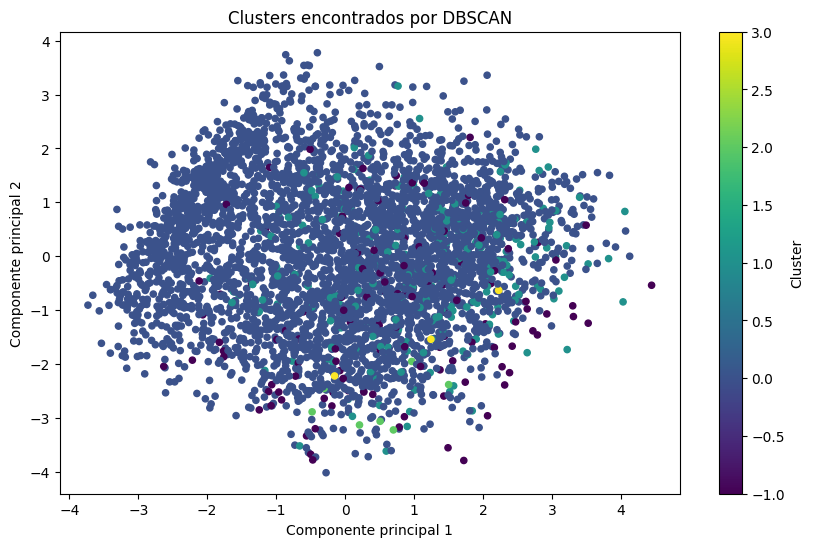

In [233]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    semilla_pca[:, 0],
    semilla_pca[:, 1],
    c=semilla["cluster"],
    cmap="viridis",
    s=20
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clusters encontrados por DBSCAN")
plt.colorbar(label="Cluster")

plt.show()

La representación mediante PCA permitió visualizar los clusters identificados por DBSCAN. Se observa una concentración diferenciada de los registros principalmente entre los clusters de mayor tamaño, aunque existe cierto solapamiento entre ellos. Los dos primeros componentes principales explicaron el 27,11 % de la varianza total, por lo que la visualización representa de manera aproximada la estructura multidimensional de los datos

In [237]:
semilla.groupby("cluster").mean().round(2).T

cluster,-1,0,1,2,3
edad_meses,19.79,18.41,21.06,25.86,30.2
sexo,1.37,1.51,1.50,1.71,1.6
edad_madre,31.83,27.03,27.94,31.14,28.2
educacion_madre,3.19,3.26,3.12,2.57,3.4
area,1.37,1.37,1.26,1.57,1.6
region,3.23,3.01,2.93,4.71,3.4
quintil_riqueza,2.54,2.45,2.76,1.86,2.0
lactancia_alguna_vez,1.41,1.00,2.00,1.00,2.0
lactancia_actual,1.72,1.58,2.00,2.00,2.0
alimento_fortificado,1.66,1.83,1.83,1.86,2.0


Interpretación para Proyecto Semilla

Los resultados muestran que dentro de la población actualmente clasificada como sin riesgo existen diferentes perfiles de características sociodemográficas, alimentarias y de salud.

K-Means permitió identificar cinco perfiles generales, mientras que DBSCAN permitió reconocer una estructura predominantemente concentrada en un grupo y, adicionalmente, identificar observaciones que se alejaban de los patrones de densidad predominantes.

Estos resultados sugieren que una estrategia preventiva podría complementar la clasificación nutricional tradicional con información relacionada con:

edad del niño;
condiciones socioeconómicas;
características de la madre;
lactancia;
frecuencia de alimentación;
consumo de alimentos;
vacunación;
presencia reciente de diarrea, fiebre o tos.

La finalidad no sería diagnosticar anticipadamente desnutrición, sino identificar perfiles que puedan ser considerados para seguimiento, orientación nutricional o intervención preventiva.


10. Limitaciones
El análisis presenta algunas limitaciones. En primer lugar, los datos corresponden a una medición de la población y no permiten establecer causalidad ni determinar qué niños desarrollarán desnutrición en el futuro. Por lo tanto, los perfiles identificados deben interpretarse como patrones de vulnerabilidad potencial y no como diagnósticos.

Además, la separación encontrada mediante K-Means fue limitada, lo que indica que existen características compartidas entre los grupos. Finalmente, DBSCAN identificó una gran concentración de observaciones en un grupo predominante, por lo que sus resultados deben utilizarse como complemento y no como único criterio de priorización.

Conclusiones

El análisis permitió identificar diferentes perfiles dentro de una población de 4.206 niños y niñas de 0 a 36 meses que actualmente no presentan riesgo nutricional. Mediante K-Means se identificaron cinco grupos con características diferenciadas, mientras que DBSCAN permitió reconocer una estructura predominantemente homogénea y detectar 125 observaciones que no se ajustaron claramente a los patrones de densidad predominantes.

Los resultados muestran que la población considerada sin riesgo no necesariamente presenta las mismas condiciones sociodemográficas, alimentarias y de salud. Esta heterogeneidad representa una oportunidad para fortalecer estrategias de prevención y seguimiento.

Desde la perspectiva de Proyecto Semilla, los modelos de aprendizaje no supervisado pueden utilizarse como una herramienta exploratoria para identificar perfiles de vulnerabilidad potencial y orientar la priorización de acciones preventivas. Sin embargo, los resultados no deben interpretarse como un diagnóstico ni como una predicción de desnutrición, debido a que los datos utilizados no permiten establecer causalidad ni evolución temporal.

Como siguiente etapa, los perfiles identificados podrían complementarse con seguimiento longitudinal y validación con profesionales del área nutricional, con el propósito de evaluar si las características encontradas efectivamente se relacionan con una mayor probabilidad de desarrollar riesgo nutricional.